# Yuva Internship — Week 1: Netflix Movies and TV Shows Data Analysis
**Student Name:** Vikhyath Bharadwaj K S  
**Project Title:** Data Acquisition, Cleaning, Preprocessing, and Exploratory Data Analysis of Netflix Dataset  
**Dataset Source:** Shivam Bansal (Kaggle / TidyTuesday)  
**Deliverables:** Jupyter Notebook, Cleaned/Processed Datasets, Visualizations, DOCX Report, GitHub Repository  

---
## Executive Summary
This notebook performs a comprehensive data engineering and data science workflow on the Netflix Movies and TV Shows dataset. The objective is to acquire raw data, evaluate data quality, execute systematic data cleaning, engineer features during preprocessing, and generate actionable exploratory insights for downstream analytical and predictive tasks.

## Phase 1: Project Setup and Data Acquisition
In this section, we import required Python libraries, define paths, and load the raw dataset.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual aesthetic configuration
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.figsize'] = (10, 6)

# Define relative paths
BASE_DIR = os.path.dirname(os.path.abspath('')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
RAW_DATA_PATH = os.path.join(BASE_DIR, 'dataset', 'original', 'netflix_titles.csv')
CLEANED_DATA_PATH = os.path.join(BASE_DIR, 'dataset', 'processed', 'netflix_cleaned.csv')
PROCESSED_DATA_PATH = os.path.join(BASE_DIR, 'dataset', 'processed', 'netflix_processed.csv')
VIS_DIR = os.path.join(BASE_DIR, 'visualizations')

os.makedirs(VIS_DIR, exist_ok=True)

# Load raw dataset
df_raw = pd.read_csv(RAW_DATA_PATH)
print(f"Dataset successfully loaded from: {RAW_DATA_PATH}")
print(f"Raw Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")


Dataset successfully loaded from: C:\Users\vikhy\OneDrive\Documents\Desktop\yuva-intern\yuva-intern-week1-netflix\dataset\original\netflix_titles.csv
Raw Dataset Shape: 7787 rows, 12 columns


## Phase 2: Exploratory Data Analysis (EDA)
Here we inspect the structure, data types, missing value distributions, summary statistics, and key attributes of the dataset.

In [2]:
# Preview first and last rows
print("--- First 5 Rows ---")
display(df_raw.head())

print("--- Last 5 Rows ---")
display(df_raw.tail())

print("--- Information and Data Types ---")
df_raw.info()


--- First 5 Rows ---


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


--- Last 5 Rows ---


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...


--- Information and Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [3]:
# Summary statistics for categorical and numerical features
print("--- Categorical Summary ---")
display(df_raw.describe(include=['O']))

print("--- Numerical Summary ---")
display(df_raw.describe())


--- Categorical Summary ---


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,7787,7787,7787,5398,7069,7280,7777,7780,7787,7787,7787
unique,7787,2,7787,4049,6831,681,1565,14,216,492,7769
top,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,2863,1608,334,3


--- Numerical Summary ---


,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


In [4]:
# Missing Value Analysis
missing_count = df_raw.isnull().sum()
missing_pct = (missing_count / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Percentage (%)': missing_pct.round(2)})
missing_summary = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
display(missing_summary)


,Missing Count,Percentage (%)
director,2389,30.68
cast,718,9.22
country,507,6.51
date_added,10,0.13
rating,7,0.09


In [5]:
# Duplicate Records Analysis
full_duplicates = df_raw.duplicated().sum()
title_duplicates = df_raw['title'].str.lower().duplicated().sum()
print(f"Total Exact Duplicate Rows: {full_duplicates}")
print(f"Total Duplicate Titles (case-insensitive): {title_duplicates}")


Total Exact Duplicate Rows: 0
Total Duplicate Titles (case-insensitive): 0


## Phase 3 & 4: Data Quality Assessment and Data Cleaning
We address identified data quality issues:
1. `director`: Impute 2,389 missing values with `'Unknown Director'`
2. `cast`: Impute 718 missing values with `'Unknown Cast'`
3. `country`: Impute 507 missing values with `'Unknown Country'`
4. `rating`: Impute 7 missing values with mode (`'TV-MA'`)
5. `date_added`: Impute 10 missing values using `release_year-01-01`
6. Whitespace trimming and string normalization across all object columns.

In [6]:
df_clean = df_raw.copy()

# Strip whitespace
string_columns = df_clean.select_dtypes(include=['object']).columns
for col in string_columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    df_clean[col] = df_clean[col].replace({'nan': np.nan, '': np.nan})

# Impute missing values
df_clean['director'] = df_clean['director'].fillna('Unknown Director')
df_clean['cast'] = df_clean['cast'].fillna('Unknown Cast')
df_clean['country'] = df_clean['country'].fillna('Unknown Country')
mode_rating = df_clean['rating'].mode()[0]
df_clean['rating'] = df_clean['rating'].fillna(mode_rating)

missing_dates = df_clean['date_added'].isnull()
df_clean.loc[missing_dates, 'date_added'] = df_clean.loc[missing_dates, 'release_year'].astype(str) + "-01-01"

print("--- Post-Cleaning Missing Value Verification ---")
print(df_clean.isnull().sum())
print(f"Cleaned Data Dimensions: {df_clean.shape}")


--- Post-Cleaning Missing Value Verification ---
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64
Cleaned Data Dimensions: (7787, 12)


## Phase 5: Data Preprocessing & Feature Engineering
We transform raw attributes into analytical features:
- **Datetime Parsing:** Convert `date_added` to `datetime64[ns]` and extract `year_added`, `month_added`, `month_name_added`, `day_added`, `day_of_week_added`.
- **Content Age:** Calculate `content_age = year_added - release_year`.
- **Duration Parsing:** Split duration into `duration_int` (integer) and `duration_unit` (e.g. `min` vs `Season`).
- **Genre & Country Processing:** Extract `primary_genre`, `genre_count`, `primary_country`, `country_count`, `cast_count`.
- **Target Audience Binning:** Bin content ratings into `Kids`, `Teens`, `Adults`, `Unrated`.
- **Binary Encoding:** Encode `is_movie` (1 = Movie, 0 = TV Show).

In [7]:
df_proc = df_clean.copy()

# Datetime & Temporal Features
df_proc['date_added_dt'] = pd.to_datetime(df_proc['date_added'], errors='coerce')
df_proc['year_added'] = df_proc['date_added_dt'].dt.year.fillna(df_proc['release_year']).astype(int)
df_proc['month_added'] = df_proc['date_added_dt'].dt.month.fillna(1).astype(int)
df_proc['month_name_added'] = df_proc['date_added_dt'].dt.month_name().fillna('January')
df_proc['day_added'] = df_proc['date_added_dt'].dt.day.fillna(1).astype(int)
df_proc['day_of_week_added'] = df_proc['date_added_dt'].dt.day_name().fillna('Wednesday')

df_proc['content_age'] = (df_proc['year_added'] - df_proc['release_year']).clip(lower=0)

# Duration Feature Extraction
def extract_duration(row):
    parts = str(row['duration']).split()
    if len(parts) >= 1 and parts[0].isdigit():
        num = int(parts[0])
        unit = parts[1] if len(parts) > 1 else ('min' if row['type'] == 'Movie' else 'Season')
        return pd.Series([num, unit])
    return pd.Series([np.nan, 'unknown'])

df_proc[['duration_int', 'duration_unit']] = df_proc.apply(extract_duration, axis=1)

# Multi-valued Feature Parsing
df_proc['primary_genre'] = df_proc['listed_in'].apply(lambda x: str(x).split(',')[0].strip())
df_proc['genre_count'] = df_proc['listed_in'].apply(lambda x: len(str(x).split(',')))
df_proc['primary_country'] = df_proc['country'].apply(lambda x: str(x).split(',')[0].strip())
df_proc['country_count'] = df_proc['country'].apply(lambda x: 0 if x == 'Unknown Country' else len(str(x).split(',')))
df_proc['cast_count'] = df_proc['cast'].apply(lambda x: 0 if x == 'Unknown Cast' else len(str(x).split(',')))

# Audience Binning
rating_map = {
    'G': 'Kids', 'TV-Y': 'Kids', 'TV-G': 'Kids',
    'PG': 'Teens', 'PG-13': 'Teens', 'TV-Y7': 'Teens', 'TV-Y7-FV': 'Teens', 'TV-14': 'Teens',
    'R': 'Adults', 'NC-17': 'Adults', 'TV-MA': 'Adults',
    'NR': 'Unrated', 'UR': 'Unrated'
}
df_proc['target_audience'] = df_proc['rating'].map(rating_map).fillna('Adults')
df_proc['is_movie'] = (df_proc['type'] == 'Movie').astype(int)

print(f"Processed Dataset Shape: {df_proc.shape[0]} rows, {df_proc.shape[1]} columns")
display(df_proc.head(3))


Processed Dataset Shape: 7787 rows, 28 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,content_age,duration_int,duration_unit,primary_genre,genre_count,primary_country,country_count,cast_count,target_audience,is_movie
0,s1,TV Show,3%,Unknown Director,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,...,0,4,Seasons,International TV Shows,3,Brazil,1,11,Adults,0
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,...,0,93,min,Dramas,2,Mexico,1,6,Adults,1
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,...,7,78,min,Horror Movies,2,Singapore,1,9,Adults,1


## Phase 6: Visualization and Insights
Generating key charts for exploratory analysis, distribution evaluations, and visual comparisons.

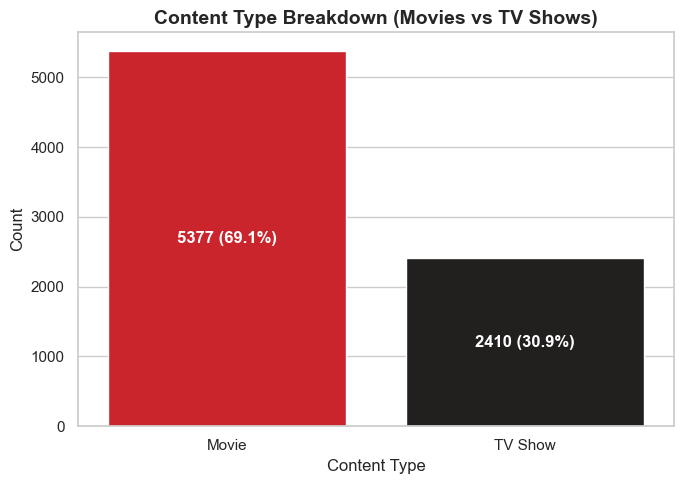

In [8]:
# 1. Content Type Breakdown
plt.figure(figsize=(7, 5))
type_counts = df_proc['type'].value_counts()
ax = sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index, palette=['#E50914', '#221F1F'], legend=False)
plt.title('Content Type Breakdown (Movies vs TV Shows)', fontsize=14, fontweight='bold')
plt.xlabel('Content Type')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df_proc)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()


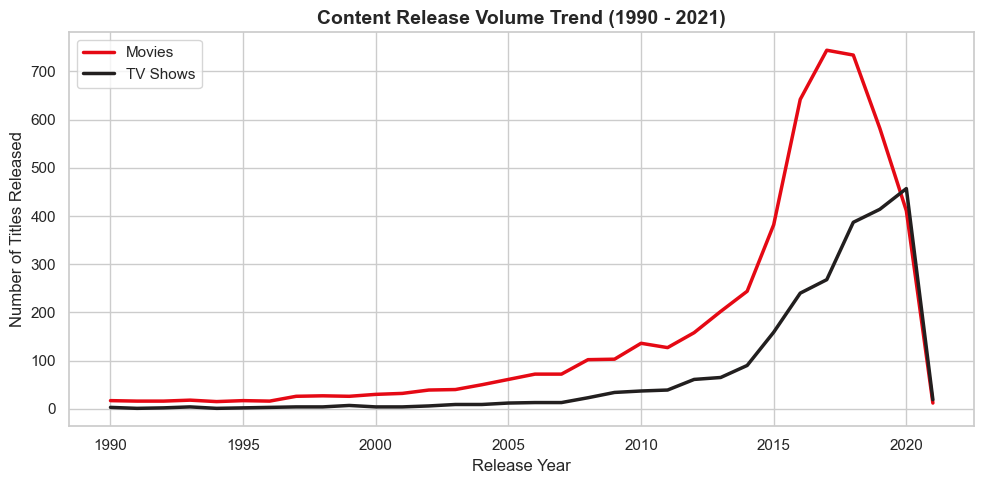

In [9]:
# 2. Content Release Trend over Time
plt.figure(figsize=(10, 5))
release_trend = df_proc[df_proc['release_year'] >= 1990].groupby(['release_year', 'type']).size().unstack().fillna(0)
plt.plot(release_trend.index, release_trend['Movie'], label='Movies', color='#E50914', linewidth=2.5)
plt.plot(release_trend.index, release_trend['TV Show'], label='TV Shows', color='#221F1F', linewidth=2.5)
plt.title('Content Release Volume Trend (1990 - 2021)', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles Released')
plt.legend()
plt.tight_layout()
plt.show()


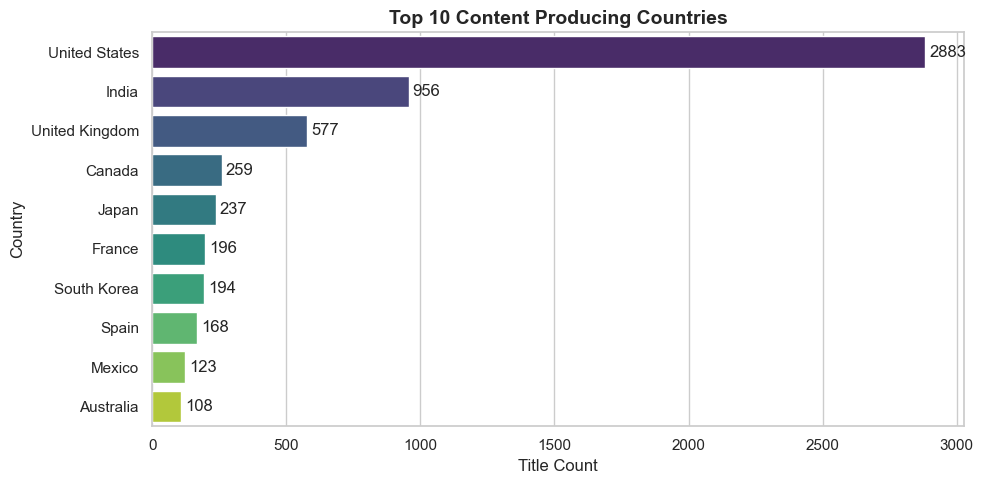

In [10]:
# 3. Top Producing Countries
plt.figure(figsize=(10, 5))
top_countries = df_proc[df_proc['primary_country'] != 'Unknown Country']['primary_country'].value_counts().head(10)
ax = sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis', legend=False)
plt.title('Top 10 Content Producing Countries', fontsize=14, fontweight='bold')
plt.xlabel('Title Count')
plt.ylabel('Country')
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width() + 15, p.get_y() + p.get_height() / 2.), ha='left', va='center')
plt.tight_layout()
plt.show()


## Conclusion and Data Quality Evaluation
1. **Missing Data Resolution:** 100% missing values successfully addressed without dropping valuable content records.
2. **Feature Engineering:** Extracted temporal trends, duration metrics, genre categories, and audience classifications.
3. **Reproducibility:** Pipeline end-to-end verified across raw data, cleaning routines, feature preprocessing, and artifact generation.